# 1. 사이킷런 소개와 특징

# 2. 첫 번째 머신러닝 만들어 보기 - 붓꽃 품종 예측하기

#2.1 학습(train)과 테스트(test) 데이터 분리 - train_test_split()
from sklearn.datasets import load_iris
from sklearn.tree import DecisionTreeClassifier
from sklearn.model_selection import train_test_split

In [1]:
#2.1 데이터 세트를 dataframe으로 저장하기
from sklearn.datasets import load_iris
import pandas as pd

##불꽃 데이터 세트를 로딩합니다.
iris = load_iris()

##iris.target은 Iris 데이터 세트에서 피처(feature)만으로 된 데이터를 numpy로 가지고 있습니다
iris_data = iris.data
# > 정보를 넣고 그것에 대한 이름을 얻고자 할 때, iris_data는 넣는 정보에 해당

#iris.target은 붓꽃 데이터 세트에서 레이블(결정값) 데이터를 numpy로 가지고 있습니다.
iris_label = iris.target
# > 정보를 넣고 그것에 대한 이름을 얻고자 할 때, iris_label은 얻게 되는 이름에 해당
print('iris target값:', iris_label)
print('iris target명:', iris.target_names)

##불꽃 데이터 세트를 자세히 보기 위해 DataFrame으로 변환
iris_df = pd.DataFrame(data=iris_data, columns=iris.feature_names)
iris_df['label'] = iris.target
iris_df.head(3)

#Setosa - 0 / versicolor - 1 / virginica - 2

iris target값: [0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0
 0 0 0 0 0 0 0 0 0 0 0 0 0 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1
 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 2 2 2 2 2 2 2 2 2 2 2
 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2
 2 2]
iris target명: ['setosa' 'versicolor' 'virginica']


,sepal length (cm),sepal width (cm),petal length (cm),petal width (cm),label
0,5.1,3.5,1.4,0.2,0
1,4.9,3.0,1.4,0.2,0
2,4.7,3.2,1.3,0.2,0


In [3]:
#2.2 test와 trian 데이터 분리하기

from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(iris_data,iris_label, test_size=0.2, random_state=11)

In [7]:
#2.3 객체 생성 및 학습 수행 

#DecisionTreeClassifier 객체 생성
from sklearn.tree import DecisionTreeClassifier

dt_clf = DecisionTreeClassifier(random_state=11)

##학습 수행
dt_clf.fit(X_train, y_train)

,criterion,'gini'
,splitter,'best'
,max_depth,None
,min_samples_split,2
,min_samples_leaf,1
,min_weight_fraction_leaf,0.0
,max_features,None
,random_state,11
,max_leaf_nodes,None
,min_impurity_decrease,0.0
,class_weight,None


sklearn.datasets: 여기는 load_iris(), load_digits() 같은 '데이터 가방'
sklearn.tree: 여기는 DecisionTreeClassifier 같은 '학습 기계(모델)

In [9]:
#2.4 테스트 시행
##학습이 완료된 DecisionTreeClassifier 객체에서 테스트 데이터 세트로 예측 수행.
pred = dt_clf.predict(X_test)

In [11]:
#2.5 정확도 확인(성능 평가)
from sklearn.metrics import accuracy_score
print('예측 정확도: {0:4f}'.format(accuracy_score(y_test,pred)))

예측 정확도: 0.933333


In [ ]:
순서 정리
1. 데이터 세트 분리 : 학습과 테스트 데이터 분리
2. 모델 학습 : 학습 데이터를 기반으로 ML 알고리즘을 적용해 모델을 학습
3. 예측 수행 : 학습된 ML 모델을 이용해 테스트 데이터의 분류를 예측
4. 평가 : 예측된 결괏값과 테스트 데이터의 실제 결괏값을 비교해 ML 모델 서능을 평가

# 3. 사이킷런의 기반 프레임워크 익히기

#3.1 Estimator 이해 및 fit(), predict() 메서드
fit(X, y): 학습 - 알고리즘이 데이터의 패턴을 학습하여 내부 파라미터를 업데이트
predict(X): 예측 - 학습된 모델을 사용하여 새로운 데이터에 대한 결과를 내놓는 단계
transform(): 적용 - 학습된 통계값을 바탕으로 실제 데이터를 변환
fit_transform(): 학습&적용 - 학습과 변환을 동시에 수행하는 편리한 메서드

In [ ]:
#3.2 사이킷런의 주요 모듈

In [ ]:
#3.3 내장된 예제 데이터 세트

In [1]:
#3.3.1 붓꽃 예제
from sklearn.datasets import load_iris

iris_data = load_iris()
print(type(iris_data))

<class 'sklearn.utils._bunch.Bunch'>


In [2]:
#3.3.2 keys() : 피처들의 데이터 값
keys = iris_data.keys()
print('붓꽃 데이터 세트의 키들:', keys)

붓꽃 데이터 세트의 키들: dict_keys(['data', 'target', 'frame', 'target_names', 'DESCR', 'feature_names', 'filename', 'data_module'])


In [3]:
#3.3.3 데이터 확인
print('\n feature_names의 type:', type(iris_data.feature_names))
print(' feature_names의 shape:', len(iris_data.feature_names))
print(iris_data.feature_names)

print('\n feature_names의 type:', type(iris_data.target_names))
print(' feature_names의 shape:', len(iris_data.target_names))
print(iris_data.target_names)

print('\n data의 type:', type(iris_data.data))
print('data의 shape:', iris_data.data.shape)
print(iris_data['data'])

print('\n target의 type:', type(iris_data.target))
print('target의 shape:', iris_data.target.shape)
print(iris_data['target'])


 feature_names의 type: <class 'list'>
 feature_names의 shape: 4
['sepal length (cm)', 'sepal width (cm)', 'petal length (cm)', 'petal width (cm)']

 feature_names의 type: <class 'numpy.ndarray'>
 feature_names의 shape: 3
['setosa' 'versicolor' 'virginica']

 data의 type: <class 'numpy.ndarray'>
data의 shape: (150, 4)
[[5.1 3.5 1.4 0.2]
 [4.9 3.  1.4 0.2]
 [4.7 3.2 1.3 0.2]
 [4.6 3.1 1.5 0.2]
 [5.  3.6 1.4 0.2]
 [5.4 3.9 1.7 0.4]
 [4.6 3.4 1.4 0.3]
 [5.  3.4 1.5 0.2]
 [4.4 2.9 1.4 0.2]
 [4.9 3.1 1.5 0.1]
 [5.4 3.7 1.5 0.2]
 [4.8 3.4 1.6 0.2]
 [4.8 3.  1.4 0.1]
 [4.3 3.  1.1 0.1]
 [5.8 4.  1.2 0.2]
 [5.7 4.4 1.5 0.4]
 [5.4 3.9 1.3 0.4]
 [5.1 3.5 1.4 0.3]
 [5.7 3.8 1.7 0.3]
 [5.1 3.8 1.5 0.3]
 [5.4 3.4 1.7 0.2]
 [5.1 3.7 1.5 0.4]
 [4.6 3.6 1.  0.2]
 [5.1 3.3 1.7 0.5]
 [4.8 3.4 1.9 0.2]
 [5.  3.  1.6 0.2]
 [5.  3.4 1.6 0.4]
 [5.2 3.5 1.5 0.2]
 [5.2 3.4 1.4 0.2]
 [4.7 3.2 1.6 0.2]
 [4.8 3.1 1.6 0.2]
 [5.4 3.4 1.5 0.4]
 [5.2 4.1 1.5 0.1]
 [5.5 4.2 1.4 0.2]
 [4.9 3.1 1.5 0.2]
 [5.  3.2 1.2 0.2]
 [

# 4. Model Selection 모듈 소개

In [6]:
#4.1 학습/테스트 데이터 세트 분리 - train_test_split()
#4.1.1 학습과 테스트를 동일한 데이터로 진행한 경우

from sklearn.datasets import load_iris
from sklearn.tree import DecisionTreeClassifier
from sklearn.metrics import accuracy_score

iris = load_iris()
dt_clf = DecisionTreeClassifier()
train_data = iris.data
train_label = iris.target
dt_clf.fit(train_data,train_label)

##학습 데이터 세트로 예측 수행 및 결과
pred = dt_clf.predict(train_data)
print('예측 정확도:', accuracy_score(train_label,pred))

#정확도가 100%가 나옴 >> ㅋㅋ 잘못됨

예측 정확도: 1.0


In [8]:
#4.1.2 학습과 테스트를 다르게
from sklearn.tree import DecisionTreeClassifier
from sklearn.metrics import accuracy_score
from sklearn.datasets import load_iris
from sklearn.model_selection import train_test_split

dt_clf = DecisionTreeClassifier()
iris_data = load_iris()

X_train, X_test, y_train, y_test = train_test_split(iris_data.data, iris_data.target, test_size=0.3, random_state=121)

In [12]:
#4.1.2 학습과 테스트를 다르게 > 정확도 확인
dt_clf.fit(X_train, y_train)
pred=dt_clf.predict(X_test)
print('예측 정확도: {0:.4f}'. format(accuracy_score(y_test, pred)))

예측 정확도: 0.9556


In [ ]:
#4.2 교차 검증

In [14]:
#4.2 방법1. K 폴드 교차 검증

#4.2.1 KFold 객체를 생성
from sklearn.tree import DecisionTreeClassifier
from sklearn.metrics import accuracy_score
from sklearn.model_selection import KFold
import numpy as np

iris = load_iris()
features = iris.data
label = iris.target
dt_clf = DecisionTreeClassifier(random_state =156)

##5개의 폴드 세트로 분리하는 KFold 객체와 폴드 세트별 정화도를 잠을 리스트 객체 생성.
kfold = KFold(n_splits=5)
cv_accuracy = []
print('붓꽃 데이터 세트 쿠기:', features.shape[0])

붓꽃 데이터 세트 쿠기: 150


In [16]:
#4.2.2 예측 정확도를 측정 이후 검증 데이터 세트의 인덱스도 추출
n_iter = 0

#KFold 객체의 split()를 호출하면 폴드별 학습용, 검증용 테스트의 로우 인덱스를 array로 반환
for train_index, test_index in kfold.split(features):
    #kfold.split()반환된 인덱스를 이용해 학습용, 검증용 테스트 데이터 추출
    X_train, X_test = features[train_index], features[test_index]
    y_train, y_test = label[train_index], label[test_index]

    ##(1) 학습 및 예측 _ fit(), predict()
    dt_clf.fit(X_train, y_train)
    pred = dt_clf.predict(X_test)
    n_iter +=1

    ##반복 시마다 정확도 측정
    accuracy = np.round(accuracy_score(y_test,pred),4)
    train_size = X_train.shape[0]
    # X_train.shape: 만약 데이터가 120줄이고 특징(Feature)이 4개라면 (120, 4)라는 값을 가집니다.
    # X_train.shape[0]: 첫 번째 값인 **행의 개수(데이터 샘플 수)**를 가져옵니다. (위 예시에서는 120)
    test_size = X_test.shape[0]
    print('\n#{0} 교차 검증 정확도 :{1}, 학습 데이터 크기: {2}, 검증 데이터 크기: {3}'
          .format(n_iter, accuracy, train_size, test_size))
    print('#{0} 검증 세트 인덱스:{1}'.format(n_iter, test_index))
    cv_accuracy.append(accuracy)

#개별 iteration 별 정확도를 합하여 평균 정확도를 게산
print('\n## 평균 검증 정확도:', np.mean(cv_accuracy))


#1 교차 검증 정확도 :1.0, 학습 데이터 크기: 120, 검증 데이터 크기: 30
#1 검증 세트 인덱스:[ 0  1  2  3  4  5  6  7  8  9 10 11 12 13 14 15 16 17 18 19 20 21 22 23
 24 25 26 27 28 29]

#2 교차 검증 정확도 :0.9667, 학습 데이터 크기: 120, 검증 데이터 크기: 30
#2 검증 세트 인덱스:[30 31 32 33 34 35 36 37 38 39 40 41 42 43 44 45 46 47 48 49 50 51 52 53
 54 55 56 57 58 59]

#3 교차 검증 정확도 :0.8667, 학습 데이터 크기: 120, 검증 데이터 크기: 30
#3 검증 세트 인덱스:[60 61 62 63 64 65 66 67 68 69 70 71 72 73 74 75 76 77 78 79 80 81 82 83
 84 85 86 87 88 89]

#4 교차 검증 정확도 :0.9333, 학습 데이터 크기: 120, 검증 데이터 크기: 30
#4 검증 세트 인덱스:[ 90  91  92  93  94  95  96  97  98  99 100 101 102 103 104 105 106 107
 108 109 110 111 112 113 114 115 116 117 118 119]

#5 교차 검증 정확도 :0.7333, 학습 데이터 크기: 120, 검증 데이터 크기: 30
#5 검증 세트 인덱스:[120 121 122 123 124 125 126 127 128 129 130 131 132 133 134 135 136 137
 138 139 140 141 142 143 144 145 146 147 148 149]

## 평균 검증 정확도: 0.9


In [17]:
#4.3 방법2. Stratified K 폴드 : 치우친 데이터
##레이블 분포를 고려하여 학습, 검증 세트에 적용

In [19]:
#4.3.1 분포도 확인
import pandas as pd

iris = load_iris()
iris_df = pd.DataFrame(data=iris.data, columns=iris.feature_names)
iris_df['label']=iris.target
iris_df['label'].value_counts()

label
0    50
1    50
2    50
Name: count, dtype: int64

In [20]:
#4.3.2 KFold를 생성
kfold = KFold(n_splits=3)
n_iter = 0
for train_index, test_index in kfold.split(iris_df):
    n_iter +=1
    label_train=iris_df['label'].iloc[train_index]
    label_test=iris_df['label'].iloc[test_index]
    print('##교차 검증: {0}'.format(n_iter))
    print('학습 레이블 데이터 분포:\n', label_train.value_counts())
    print('검증 레이블 데이터 분포:\n', label_test.value_counts())

    ##결과를 보면 전체적으로 분포가 치우치는 경향을 띄게 됨
    ##이걸 StratifiedKFold로 해결해야함

##교차 검증: 1
학습 레이블 데이터 분포:
 label
1    50
2    50
Name: count, dtype: int64
검증 레이블 데이터 분포:
 label
0    50
Name: count, dtype: int64
##교차 검증: 2
학습 레이블 데이터 분포:
 label
0    50
2    50
Name: count, dtype: int64
검증 레이블 데이터 분포:
 label
1    50
Name: count, dtype: int64
##교차 검증: 3
학습 레이블 데이터 분포:
 label
0    50
1    50
Name: count, dtype: int64
검증 레이블 데이터 분포:
 label
2    50
Name: count, dtype: int64


In [21]:
#4.3.3 StratifiedKFold 적용 방법
##KFold와 다른 점 : 다른 것은 다 동일, 학습과 테스트 데이터를 나눌 때 분포에 따라서 나눔
from sklearn.model_selection import StratifiedKFold

skf = StratifiedKFold(n_splits=3)
n_inter=0

for train_index, test_index in skf.split(iris_df, iris_df['label']):
    n_iter +=1
    label_train=iris_df['label'].iloc[train_index]
    label_test=iris_df['label'].iloc[test_index]
    print('##교차 검증: {0}'.format(n_iter))
    print('학습 레이블 데이터 분포:\n', label_train.value_counts())
    print('검증 레이블 데이터 분포:\n', label_test.value_counts())

##교차 검증: 4
학습 레이블 데이터 분포:
 label
2    34
0    33
1    33
Name: count, dtype: int64
검증 레이블 데이터 분포:
 label
0    17
1    17
2    16
Name: count, dtype: int64
##교차 검증: 5
학습 레이블 데이터 분포:
 label
1    34
0    33
2    33
Name: count, dtype: int64
검증 레이블 데이터 분포:
 label
0    17
2    17
1    16
Name: count, dtype: int64
##교차 검증: 6
학습 레이블 데이터 분포:
 label
0    34
1    33
2    33
Name: count, dtype: int64
검증 레이블 데이터 분포:
 label
1    17
2    17
0    16
Name: count, dtype: int64


In [25]:
#4.3.4 교차검증
dt_clf = DecisionTreeClassifier(random_state=156)

skfold = StratifiedKFold(n_splits =3)
n_iter = 0
cv_accuracy=[]

##StratifiedKFold의 split() 호출시 반드시 레이블 데이터 세트도 추가 입력 필요
for train_index, test_index in skfold.split(features, label):
    ##split()으로 변환된 인덱스를 이용해 학습용, 검증용 테스트 데이터 추출
    X_train, X_test = features[train_index], features[test_index]
    y_train, y_test = label[train_index], label[test_index]

    ##(1) 학습 및 예측
    dt_clf.fit(X_train,y_train)
    pred=dt_clf.predict(X_test)

    ##(2) 반복 시마다 정확도 측정
    n_iter+=1
    accuracy =np.round(accuracy_score(y_test,pred),4)
    train_size =X_train.shape[0]
    test_size =X_test.shape[0]
    print('\n#{0} 교차 검증 정확도 :{1}, 학습 데이터 크기: {2}, 검증 데이터 크기: {3}'.format(n_iter,accuracy,train_size,test_size))
    print('#{0} 검증 세트 인덱스:{1}'.format(n_iter, test_index))
    cv_accuracy.append(accuracy)

#교차 검증별 정확도 및 평균 정확도 게산
print('\n## 교차 검증별 정확도:',np.round(cv_accuracy,4))
print('##평균 검증 정확도:',np.round(np.mean(cv_accuracy),4))


#1 교차 검증 정확도 :0.98, 학습 데이터 크기: 100, 검증 데이터 크기: 50
#1 검증 세트 인덱스:[  0   1   2   3   4   5   6   7   8   9  10  11  12  13  14  15  16  50
  51  52  53  54  55  56  57  58  59  60  61  62  63  64  65  66 100 101
 102 103 104 105 106 107 108 109 110 111 112 113 114 115]

#2 교차 검증 정확도 :0.94, 학습 데이터 크기: 100, 검증 데이터 크기: 50
#2 검증 세트 인덱스:[ 17  18  19  20  21  22  23  24  25  26  27  28  29  30  31  32  33  67
  68  69  70  71  72  73  74  75  76  77  78  79  80  81  82 116 117 118
 119 120 121 122 123 124 125 126 127 128 129 130 131 132]

#3 교차 검증 정확도 :0.98, 학습 데이터 크기: 100, 검증 데이터 크기: 50
#3 검증 세트 인덱스:[ 34  35  36  37  38  39  40  41  42  43  44  45  46  47  48  49  83  84
  85  86  87  88  89  90  91  92  93  94  95  96  97  98  99 133 134 135
 136 137 138 139 140 141 142 143 144 145 146 147 148 149]

## 교차 검증별 정확도: [0.98 0.94 0.98]
##평균 검증 정확도: 0.9667


#4.4 교차 검증을 보다 간편하게 - cross_val_score()
1. 폴드 세트 설정: KFold(n_splits=5)라고 선언
2. for문 루프: 5번의 시험을 치르기 위해 반복문을 돌리는 것
3. 인덱스 추출: kfold.split()이 주는 인덱스 번호를 받아와서, 어디가 공부용(Train)이고 어디가 시험용(Test)인지 번호를 매기는 단계
4. 학습/예측: fit(), predict() 함수
5. 정확도 계산: accuracy_score()를 통해 실제 정답과 모델이 낸 답을 비교해 점수를 매기는 단계
> 이 모든 단계를 한 번에 처리함 : cross_val_score()

In [26]:
from sklearn.tree import DecisionTreeClassifier
from sklearn.model_selection import cross_val_score, cross_validate
from sklearn.datasets import load_iris

iris_data=load_iris()
dt_clf = DecisionTreeClassifier(random_state=156)

data = iris_data.data
label = iris_data.target

##성능 지표는 정확도, 교차 검증 세트는 3개
scores = cross_val_score(dt_clf, data, label, scoring='accuracy', cv=3)
print('교차 검증별 정확도:', np.round(scores,4))
print('평균 검증 정확도:',np.round(np.mean(scores),4))


교차 검증별 정확도: [0.98 0.94 0.98]
평균 검증 정확도: 0.9667


In [ ]:
#4.4 GridSearchCV - 교차 검증과 최적 하이퍼 파라미터 튜닝을 한 번에
#머신러닝에서 **하이퍼 파라미터(Hyperparameter)**는 한마디로 모델이라는 
#기계를 돌리기 전에 사람이 직접 손으로 맞춰주는 '설정값'

In [27]:
#4.4.1 파라미터 정의
grid_parameters = {'max_depth':[1,2,3],'min_samples_split':[2,3]}

In [35]:
#4.4.2 GridSearchCV : 최적의 하이퍼 파라미터를 찾아줌

from sklearn.datasets import load_iris
from sklearn.model_selection import GridSearchCV
from sklearn.tree import DecisionTreeClassifier

#데이터를 로딩하고 학습 데이터와 테스트 데이터 분리
iris_data=load_iris()
X_train, X_test, y_train, y_test = train_test_split(iris_data.data, iris_data.target, test_size=0.2, random_state=121)
dtree=DecisionTreeClassifier()

### 파라미터를 딕셔너리 형태로 설정
parameters = {'max_depth':[1,2,3], 'min_samples_split':[2,3]}

In [38]:
#4.4.3 주요 칼럼만 발췌, GridSearchCV의 동작 확인
import pandas as pd
#param_grid의 하이퍼 파라미터를 3개의 train, test set fold로 나누어 테스트 수행 설정.
###refit=True가 default임. True이면 가장 좋은 파라미터 설정으로 재학습
grid_dtree = GridSearchCV(dtree, param_grid=parameters, cv=3, refit=True)

##불꽃 학습 데이터로 param_grid의 하이퍼 파라미터를 순차적으로 학습/평가
grid_dtree.fit(X_train, y_train)

##GridSearchCV 결과를 추출해 DataFrame으로 변환
scores_df=pd.DataFrame(grid_dtree.cv_results_)
scores_df[['params','mean_test_score','rank_test_score','split0_test_score','split1_test_score','split2_test_score']]

,params,mean_test_score,rank_test_score,split0_test_score,split1_test_score,split2_test_score
0,"{'max_depth': 1, 'min_samples_split': 2}",0.700000,5,0.700,0.7,0.70
1,"{'max_depth': 1, 'min_samples_split': 3}",0.700000,5,0.700,0.7,0.70
2,"{'max_depth': 2, 'min_samples_split': 2}",0.958333,3,0.925,1.0,0.95
3,"{'max_depth': 2, 'min_samples_split': 3}",0.958333,3,0.925,1.0,0.95
4,"{'max_depth': 3, 'min_samples_split': 2}",0.975000,1,0.975,1.0,0.95
5,"{'max_depth': 3, 'min_samples_split': 3}",0.975000,1,0.975,1.0,0.95


# 5. 데이터 전처리

### 머신러닝의 3단계 프로세스
> [1.데이터 준비] → [2.데이터 전처리] → [3.모델 학습 및 예측]
>> 1. 데이터 준비 : 데이터 로드, 결측치 확인, 시각화
>> 2. 데이터 전처리 : 인코딩, 스케일링, 데이터 분할
>> 3. 모델 학습 및 예측 : 알고리즘 학습, 결과 예측, 평가

### 사이킷런(Scikit-learn)의 핵심 구성
- 5장 데이터 전처리 part - 변환기 (Transformer)
> 데이터를 머신러닝 돌리기 편하도록 '변형'하는 도구
>> StandardScaler, MinMaxScaler, LabelEncoder, OneHotEncoder
>>> **fit()**: 데이터의 특징(평균, 최댓값 등)을 학습하여 기준을 잡음.
>>> **transform()**: 그 기준에 맞춰 데이터를 변환함.
>>> **fit_transform()**: 두 과정을 한 번에 수행함.

- 3장 사이킷런의 기반 프레임워크 익히기 - 추정기 (Estimator)
> 데이터의 패턴을 학습시켜서 결과를 '예측'하는 알고리즘
>> DecisionTreeClassifier(결정 트리), RandomForest, LogisticRegression
>>> **fit()**: 데이터 간의 관계(패턴)를 학습함. (전처리의 fit과는 의미가 조금 다름)
>>> **predict()**: 학습한 패턴을 바탕으로 새로운 데이터의 정답을 예측함.


## 5.1 데이터 인코딩

1. 결손값 처리 (1장 내용)
2. 데이터 인코딩: 문자열을 숫자형으로 변환
3. 피처 스케일링과 정규화
4. 데이터 분할 (2.4장 내용)

HOW?
- 인코딩 (Encoding): 사람이 이해하는 데이터(문자, 범주 등)를 컴퓨터가 이해하기 쉬운 숫자(디지털 형식)로 바꾸는 과정입니다.
- 디코딩 (Decoding): 컴퓨터가 처리한 숫자 데이터를 사람이 읽을 수 있는 원래의 형태(문자 등)로 다시 되돌리는 과정입니다.

In [ ]:
2. 데이터 인코딩
- 레이블 인코딩(Label Encoding) 숫자
- 원-핫 인코당(One-Hot Encoding) 숫자+위치

3. 피처 스케일링과 정규화
- StandardScler - 표준화 : 평균이 0, 표준편차가 1 (평균만 0일 뿐, 값은 0~1 사이가 아닐 수도)
- MinMaxScaler - 정규화 : 데이터의 범위를 0과 1 사이로 압축 (무조건 0~1 사이)

4. 데이터 분할
- 학습 데이터와 테스트 데이터의 스케일링 변환 시 유의점

### 5.1.1 레이블 인코딩

In [39]:
from sklearn.preprocessing import LabelEncoder
items=['TV','냉장고','전자레인지','컴퓨터','선풍기','믹서','믹서']

##LabelEncoder를 객체로 생성한 후, fit()과 Transform()으로 레이블 인코딩 수행
encoder = LabelEncoder()  #encoder : 번역도구 , encoder = LabelEncoder(): 빈 사전을 하나 준비
encoder.fit(items)        #fit() (학습): 데이터에 어떤 레이블(범주)들이 있는지 파악
labels=encoder.transform(items) #transform() (적용): fit에서 만든 목록을 바탕으로 실제 데이터를 숫자로 변환
print('인코딩 변환값:', labels)

인코딩 변환값: [0 1 4 5 3 2 2]


encoder.fit(items)
> encoder(주체)야, fit(행동)해라. 그런데 items(재료)를 가지고 해

In [41]:
#5.1.1.2 labelEndcoder 객체의 classes_ 속성값으로 확인 : 사전에 적힌 단어 리스트 보기(번역X, 말 그대로 리스트)
print('인코딩 클래스:',encoder.classes_)

인코딩 클래스: ['TV' '냉장고' '믹서' '선풍기' '전자레인지' '컴퓨터']


In [42]:
#5.1.1.3 역변환 inverse_transform() : 번역기 돌려서 해석하기(번역O)
print('디코딩 원본값:', encoder.inverse_transform([4,5,2,0,1,1,3,3]))

디코딩 원본값: ['전자레인지' '컴퓨터' '믹서' 'TV' '냉장고' '냉장고' '선풍기' '선풍기']


### 5.1.2 원-핫 인코딩

In [ ]:
#5.1.2 원-핫 인코딩 : 앞서 인코딩을 했을 경우 숫자의 크기에 따라 차이가 발생, 이를 해결해주는 것
#숫자의 크기가 아닌 1로 통일한 후, 1의 위치로 구분

In [44]:
#5.1.2.1 사이킷런에서 OneHotEncoder 클래스로 변환
from sklearn.preprocessing import OneHotEncoder
import numpy as np

items=['TV','냉장고','전자레인지','컴퓨터','선풍기','믹서','믹서']

##2차원 ndarray로 변환
items=np.array(items).reshape(-1,1)

##원-핫 인코딩을 적용
oh_encoder=OneHotEncoder()
oh_encoder.fit(items)
oh_labels=oh_encoder.transform(items)

##OneHotEncoder로 변환한 결과는 희소행렬이므로 toarray()를 이용해 밀집 행렬로 변환
print('원-핫 인코딩 데이터')
print(oh_labels.toarray())
print('원-핫 인코딩 데이터 차원')
print(oh_labels.shape)

원-핫 인코딩 데이터
[[1. 0. 0. 0. 0. 0.]
 [0. 1. 0. 0. 0. 0.]
 [0. 0. 0. 0. 1. 0.]
 [0. 0. 0. 0. 0. 1.]
 [0. 0. 0. 1. 0. 0.]
 [0. 0. 1. 0. 0. 0.]
 [0. 0. 1. 0. 0. 0.]]
원-핫 인코딩 데이터 차원
(7, 6)


원-핫 인코딩(One-Hot Encoding) 주의사항
> 압축된 데이터"를 다시 풀어라 (toarray())
>> "원-핫 인코딩은 데이터를 2차원으로 세우고(reshape), 실행 후엔 압축을 풀어야(toarray) 비로소 쓸 수 있는 '공평한' 숫자 변환법이다.

In [45]:
#5.1.2.2 원-핫 인코딩을 쉽게! - get_dummies
import pandas as pd
df = pd.DataFrame({'item':['TV','냉장고','전자레인지','컴퓨터','선풍기','믹서','믹서']})
pd.get_dummies(df)

,item_TV,item_냉장고,item_믹서,item_선풍기,item_전자레인지,item_컴퓨터
0,True,False,False,False,False,False
1,False,True,False,False,False,False
2,False,False,False,False,True,False
3,False,False,False,False,False,True
4,False,False,False,True,False,False
5,False,False,True,False,False,False
6,False,False,True,False,False,False


## 5.2 피처 스케일링과 정규화

1. 표준화: 데이터를 평균이 0, 표준편차가 1인 상태 (결과 범위 제한X)
> standard scaler

2. 정규화: 데이터의 범위를 0과 1 사이(또는 -1과 1 사이)로 압축하는 것입니다. 가장 작은 값을 0, 가장 큰 값을 1
> MinMaxScaler

*[전처리 없 계산]과 [전처리]의 차이? 계산하면 되는거 아님?*
- 단순한 '계산'은 누구나 할 수 있지만, 머신러닝에서 요구하는 '기준의 고정과 관리'는 사이킷런이 훨씬 잘하기 때문
- 단순히 "숫자를 바꾸는 것"이 목적이라면 계산기로도 충분합니다. 하지만 **"일관된 기준을 유지하며 대량의 데이터를 실수 없이 처리하는 것"**이 목적이라면 사이킷런 같은 프레임워크가 필수적
- - fit()은 내부적으로는 단순한 산수를 하는 게 맞지만, 프로그래밍적으로는 **"기준점을 메모리에 저장하고 고정하는 절차"**라고 이해하시면 됩니다.

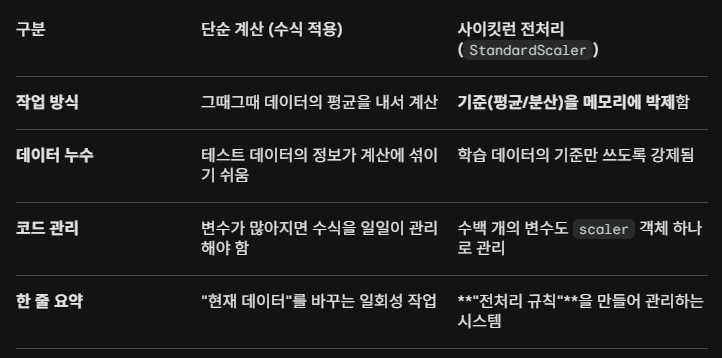

In [109]:
from IPython.display import Image
Image("1.png")

### fit()와 transform()
fit(): 값들을 계산만 하고, 원래 데이터는 전혀 건드리지 X
transform(): fit()에서 구해놓은 재료들을 가지고 진짜 수학 공식에 대입해서 데이터를 변환

> StandardScaler
>> **fit()** : 평균과 표준편차 계산 /
>> **transform()** : $z$ 변환된 새로운 값 (표준 점수)

> MinMaxScaler
>> **fit()** : 최솟값, 최댓값 계산 /
>> **transform()** : 모든 데이터를 아래의 공식에 넣어서 실제 값을 바꾸기

## 5.3 표준화: StandardScaler

In [50]:
#5.3.1 Raw Data. "계산"으로 데이터 상태 확인 - mean(), var()
from sklearn.datasets import load_iris
import pandas as pd
#붓꽃 데이터 세트를 로딩하고 DataFrame으로 변환
iris=load_iris()
iris_data=iris.data
iris_df = pd.DataFrame(data=iris_data,columns=iris.feature_names)

print('feature 들의 평균값')
print(iris_df.mean())
print('\nfeature들의 분산값')
print(iris_df.var())

feature 들의 평균값
sepal length (cm)    5.843333
sepal width (cm)     3.057333
petal length (cm)    3.758000
petal width (cm)     1.199333
dtype: float64

feature들의 분산값
sepal length (cm)    0.685694
sepal width (cm)     0.189979
petal length (cm)    3.116278
petal width (cm)     0.581006
dtype: float64


In [52]:
#5.3.1 Preprocessed Data. "사이킷런"으로 표준화 진행
from sklearn.preprocessing import StandardScaler

#StandardScaler 객체 생성
scaler= StandardScaler()
#StandardScaler로 데이터 세트 변환, fit()과 tranform()호출.
scaler.fit(iris_df)
iris_scaled = scaler.transform(iris_df)

#transform()시 스케일 변환된 데이터 세트가 Numpy ndarry로 반환돼 이를 DataFrame으로  반환
iris_df_scaled = pd.DataFrame(data=iris_scaled, columns=iris.feature_names)
print('feature 들의 평균값')
print(iris_df_scaled.mean())
print('\nfeature들의 분산값')
print(iris_df_scaled.var())

feature 들의 평균값
sepal length (cm)   -1.690315e-15
sepal width (cm)    -1.842970e-15
petal length (cm)   -1.698641e-15
petal width (cm)    -1.409243e-15
dtype: float64

feature들의 분산값
sepal length (cm)    1.006711
sepal width (cm)     1.006711
petal length (cm)    1.006711
petal width (cm)     1.006711
dtype: float64


## 5.4 정규화 : MinMaxScaler

In [54]:
#5.4.1 "계산" 안해보고 바로 "사이킷런"으로 정규화 진행
from sklearn.preprocessing import MinMaxScaler

#MinMaxScaler 객체 생성
scaler = MinMaxScaler()
#MinMaxScaler로 데이터 세트 변환. fit()과 transform()호출.
scaler.fit(iris_df)
iris_scaled=scaler.transform(iris_df)

#transform()시 스케일 변환된 데이터 세트가 Numpy ndarray로 반환돼 이를 DataFrame으로 변환
iris_df_scaled = pd.DataFrame(data=iris_scaled, columns=iris.feature_names)
print('feature 들의 최솟값')
print(iris_df_scaled.min())
print('\nfeature들의 최댓값')
print(iris_df_scaled.max())

feature 들의 최솟값
sepal length (cm)    0.0
sepal width (cm)     0.0
petal length (cm)    0.0
petal width (cm)     0.0
dtype: float64

feature들의 최댓값
sepal length (cm)    1.0
sepal width (cm)     1.0
petal length (cm)    1.0
petal width (cm)     1.0
dtype: float64


## 5.5 학습 데이터와 테스트 데이터의 스케일링 변환 시 유의점(정규화 ver)

1. 왜 스케일을 동일하게 잡아야 하는가?
- "기준이 달라질 수 있기 때문"
- 스케일링은 데이터를 특정 범위로 바꾸는 작업입니다. 이때 '무엇을 기준으로 0과 1을 정할 것인가'가 핵심입니다.

- 상황: 내 키가 180cm입니다.
- 학습 데이터 (농구 선수들): 평균 키가 200cm입니다. 여기서 180cm는 '작은 편(-1.0)'이 됩니다.
- 테스트 데이터 (일반인들): 평균 키가 170cm입니다. 여기서 180cm는 '큰 편(+1.0)'이 됩니다.
> 모델은 "아니, 아까는 180이 작다며? 왜 지금은 크다고 해?"라며 혼란에 빠지게 됩니다. 이것이 '올바른 예측 결과를 도출하지 못하는' 이유

2. 스케일을 어떻게 동일하게 잡는가?
- fit은 한 번만, transform은 매번 진행
- (1) 학습 데이터 (Train): scaler.fit()을 사용하여 데이터의 통계치(평균, 표준편차 등)를 계산하고 저장합니다. 이후 transform()으로 변환합니다.
- (2) 테스트 데이터 (Test): 별도의 fit() 과정 없이, 이미 학습 데이터로 계산된 scaler 객체를 그대로 가져와 transform()만 실행합니다.
- (3) 실전 데이터 (New): 나중에 들어올 새로운 데이터도 마찬가지로 처음에 만들어둔 scaler의 transform()만 적용합니다.

3. 어떻게 하면 Test에도 동일하게 적용되는가? fit 안했는데도??
- fit을 하는 순간, 계산된 데이터의 특징(평균, 표준편차 등)을 자신의 내부 메모리에 '저장'해두기 때문

In [57]:
#5.5.1 스케일링 크기를 다르게 했을 경우
#train 1/10, test 1/5로 스케일링(정규화)

from sklearn.preprocessing import MinMaxScaler
import numpy as np

#학습 데이터는 0부터 10까지, 테스트 데이터는 0부터 5까지 값을 가지는 데이터 세트로 생성
#Scaler 클래스의 fit(), transform()은 2차원 이상 데이터만 가능하므로 reshape(-1,1)로 차원 변경
train_array=np.arange(0,11).reshape(-1,1)
test_array=np.arange(0,6).reshape(-1,1)

In [59]:
#(1) 1/10으로 train 스케일링(정규화)

#MinMaxScaler 객체에 별도의 feature_range 파라미터 값을 지정하지 않으면 0~1값으로 변환
scaler=MinMaxScaler()

#fit()하게 되면 train_array 데이터의 최솟값이 0, 최댓값이 10으로 설정
scaler.fit(train_array)

#1/10 scale로 train_array데이터 변환함. 원본 10 > 1로 변환
train_scaled = scaler.transform(train_array)

print('원본 train_array 데이터:',np.round(train_array.reshape(-1),2))
print('scaled된 train_array 데이터:',np.round(train_scaled.reshape(-1),2))

원본 train_array 데이터: [ 0  1  2  3  4  5  6  7  8  9 10]
scaled된 train_array 데이터: [0.  0.1 0.2 0.3 0.4 0.5 0.6 0.7 0.8 0.9 1. ]


In [60]:
#(2) 1/5으로 test 스케일링(정규화)

#MinMaxScaler에 test_array를 fit()하게 되면 원본 데이터의 최솟값이 0, 최댓값이 5로 설정됨
scaler.fit(test_array)

#1/5 scale로 test_array데이터 변환함. 원본 10 > 1로 변환
test_scaled = scaler.transform(test_array)

print('원본 test_array 데이터:',np.round(test_array.reshape(-1),2))
print('scaled된 test_array 데이터:',np.round(test_scaled.reshape(-1),2))

원본 test_array 데이터: [0 1 2 3 4 5]
scaled된 test_array 데이터: [0.  0.2 0.4 0.6 0.8 1. ]


In [61]:
#(3) 테스트 데이터에 fit()을 호출하지 않고 학습 데이터로 fit() 수행 : 동일한 스케일링 (scale이 0.1로 동일)
scaler=MinMaxScaler()
scaler.fit(train_array) #여기서 한 번만 fit하고 뒤에 test에서는 fit 진행X
train_scaled=scaler.transform(train_array)
print('원본 train_array 데이터:', np.round(train_array.reshape(-1),2))
print('Scaled된 train_array 데이터:', np.round(train_scaled.reshape(-1),2))

#test_array에 scale변환할 때는 반드시 fit()을 호출하지 않고 transform()만으로 변환해야 함
test_scaled=scaler.transform(test_array)
print('원본 test_array 데이터:', np.round(test_array.reshape(-1),2))
print('Scaled된 test_array 데이터:', np.round(test_scaled.reshape(-1),2))

원본 train_array 데이터: [ 0  1  2  3  4  5  6  7  8  9 10]
Scaled된 train_array 데이터: [0.  0.1 0.2 0.3 0.4 0.5 0.6 0.7 0.8 0.9 1. ]
원본 test_array 데이터: [0 1 2 3 4 5]
Scaled된 test_array 데이터: [0.  0.1 0.2 0.3 0.4 0.5]


# 6. 사이킷런으로 수행하는 타이타닉 생존자 예측

### 머신러닝의 3단계 프로세스
> [1.데이터 준비] → [2.데이터 전처리] → [3.모델 학습 및 예측]
>> 1. 데이터 준비 : 데이터 로드, 결측치 확인, 시각화
>> 2. 데이터 전처리 : 인코딩, 스케일링, 데이터 분할
>> 3. 모델 학습 및 예측 : 알고리즘 학습, 결과 예측, 평가

### 사이킷런(Scikit-learn)의 핵심 구성
- 5장 데이터 전처리 part - 변환기 (Transformer)
> 데이터를 머신러닝 돌리기 편하도록 '변형'하는 도구
>> LabelEncoder, OneHotEncoder, StandardScaler, MinMaxScaler
>>> **fit()**: 데이터의 특징(평균, 최댓값 등)을 학습하여 기준을 잡음.
>>> **transform()**: 그 기준에 맞춰 데이터를 변환함.
>>> **fit_transform()**: 두 과정을 한 번에 수행함.

- 3장 사이킷런의 기반 프레임워크 익히기 - 추정기 (Estimator)
> 데이터의 패턴을 학습시켜서 결과를 '예측'하는 알고리즘
>> DecisionTreeClassifier(결정 트리), RandomForest, LogisticRegression
>>> **fit()**: 데이터 간의 관계(패턴)를 학습함. (전처리의 fit과는 의미가 조금 다름)
>>> **predict()**: 학습한 패턴을 바탕으로 새로운 데이터의 정답을 예측함.


# 1단계. 데이터 불러오기

### 6.1.1 데이터 로드

In [66]:
#6.1.1 데이터 불러오기 _ titanic_train.csv
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt 
import seaborn as sns
%matplotlib inline

titanic_df = pd.read_csv('./titanic_train.csv')
titanic_df.head(3)

,PassengerId,Survived,Pclass,Name,Sex,Age,SibSp,Parch,Ticket,Fare,Cabin,Embarked
0,1,0,3,"Braund, Mr. Owen Harris",male,22.0,1,0,A/5 21171,7.2500,NaN,S
1,2,1,1,"Cumings, Mrs. John Bradley (Florence Briggs Th...",female,38.0,1,0,PC 17599,71.2833,C85,C
2,3,1,3,"Heikkinen, Miss. Laina",female,26.0,0,0,STON/O2. 3101282,7.9250,NaN,S


In [67]:
#6.1.2 데이터의 칼럼 타입 확인
print('\n### 학습 데이터 정보###\n')
print(titanic_df.info())


### 학습 데이터 정보###

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 891 entries, 0 to 890
Data columns (total 12 columns):
 #   Column       Non-Null Count  Dtype  
---  ------       --------------  -----  
 0   PassengerId  891 non-null    int64  
 1   Survived     891 non-null    int64  
 2   Pclass       891 non-null    int64  
 3   Name         891 non-null    object 
 4   Sex          891 non-null    object 
 5   Age          714 non-null    float64
 6   SibSp        891 non-null    int64  
 7   Parch        891 non-null    int64  
 8   Ticket       891 non-null    object 
 9   Fare         891 non-null    float64
 10  Cabin        204 non-null    object 
 11  Embarked     889 non-null    object 
dtypes: float64(2), int64(5), object(5)
memory usage: 83.7+ KB
None


### 6.1.2 결측치 확인

In [68]:
#6.1.3 Null 처리하기
titanic_df['Age'].fillna(titanic_df['Age'].mean(), inplace=True)
titanic_df['Cabin'].fillna('N',inplace=True)
titanic_df['Embarked'].fillna('N',inplace=True)
print('데이터 세트 Null 값 개수 ',titanic_df.isnull().sum().sum())

데이터 세트 Null 값 개수  0


C:\Users\Public\Documents\ESTsoft\CreatorTemp\ipykernel_16784\2533997081.py:2: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


  titanic_df['Age'].fillna(titanic_df['Age'].mean(), inplace=True)
C:\Users\Public\Documents\ESTsoft\CreatorTemp\ipykernel_16784\2533997081.py:3: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting v

In [70]:
#6.1.4 Sex, Cabin, Embarked > (문제인 놈) > Cabin
print('Sex 값 분포:\n', titanic_df['Sex'].value_counts())
print('\n Cabin 값 분포 :\n', titanic_df['Cabin'].value_counts())
print('\n Embarked 값 분포:\n', titanic_df['Embarked'].value_counts())

Sex 값 분포:
 Sex
male      577
female    314
Name: count, dtype: int64

 Cabin 값 분포 :
 Cabin
N              687
C23 C25 C27      4
G6               4
B96 B98          4
C22 C26          3
              ... 
E34              1
C7               1
C54              1
E36              1
C148             1
Name: count, Length: 148, dtype: int64

 Embarked 값 분포:
 Embarked
S    644
C    168
Q     77
N      2
Name: count, dtype: int64


In [71]:
#6.1.5 Cabin 속성의 앞 문자만 추출
#WHY? 선실 등급을 나타내는 알파벳이 중요! 선실등급에 따라서 생존율이 바뀌는 경향 (보통 1등실의 생존율이 더 높음)
titanic_df['Cabin']=titanic_df['Cabin'].str[:1]
print(titanic_df['Cabin'].head(3))

0    N
1    C
2    N
Name: Cabin, dtype: object


In [75]:
#6.1.6 성별에 따른 생존 확인
titanic_df.groupby(['Sex','Survived'])['Survived'].count()

Sex     Survived
female  0            81
        1           233
male    0           468
        1           109
Name: Survived, dtype: int64

### 6.1.3 시각화. Seaborn 한 눈에 보는 Data

<Axes: xlabel='Sex', ylabel='Survived'>

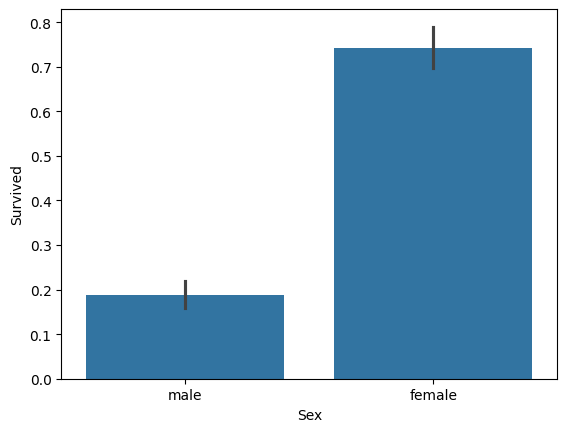

In [76]:
#6.2.1 Seaborn으로 성별에 따른 생존수 확인
sns.barplot(x='Sex', y='Survived', data=titanic_df)

<Axes: xlabel='Pclass', ylabel='Survived'>

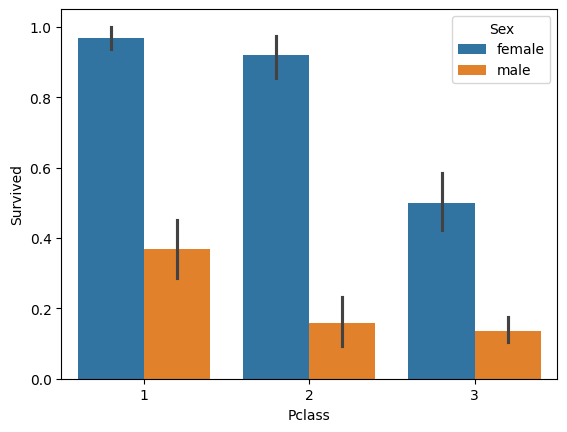

In [77]:
#6.2.2 선실등급, 생존, 성별로 나눈 seaborn
sns.barplot(x='Pclass',y='Survived',hue='Sex', data=titanic_df)

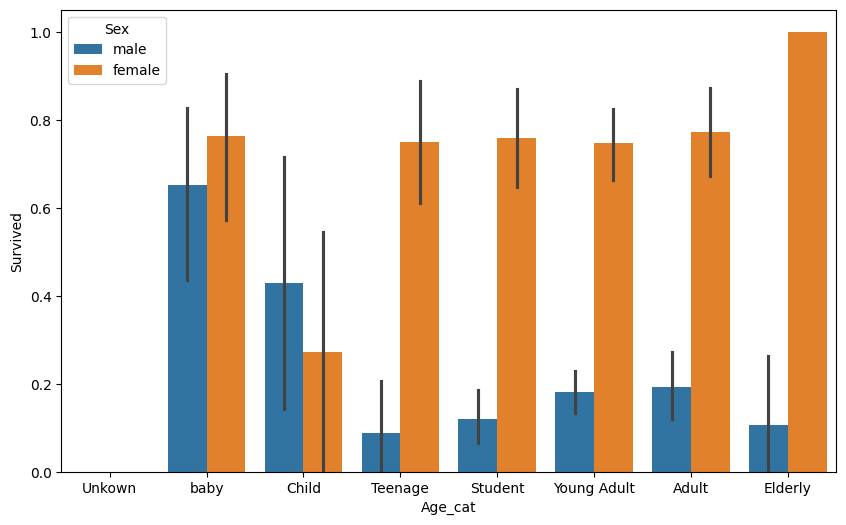

In [79]:
#6.2.3 나이에 따른 생존 확률
#입력 age에 따라 구분 값을 반환하는 함수 설정. DataFrame의 apply lambda식에 사용
def get_category(age):
    cat=''
    if age <= -1: cat ='Unkown'
    elif age<= 5: cat ='baby'
    elif age<= 12: cat ='Child'
    elif age<= 18: cat ='Teenage'
    elif age<= 25: cat ='Student'
    elif age<= 35: cat ='Young Adult'
    elif age<= 60: cat ='Adult'
    else: cat ='Elderly'

    return cat

#막대그래프의 크기 figure를 더 크게 설정
plt.figure(figsize=(10,6))

#X축의 값을 순차적으로 표시하기 위한 설정
group_names = ['Unkown','baby','Child','Teenage','Student','Young Adult','Adult','Elderly']

#lambda식에 위에서 생성한 get_category()함수를 반환값으로 지정
#get_category(X)는 입력값으로 'Age' 칼럼 값을 받아서 해당하는 cat 반환
titanic_df['Age_cat'] =  titanic_df['Age'].apply(lambda x: get_category(x))
sns.barplot(x='Age_cat',y='Survived',hue='Sex',data=titanic_df, order=group_names)
titanic_df.drop('Age_cat',axis=1,inplace=True)

# 2단계. 데이터 전처리

*Label Encoder*
> label Encoder객체: 카테고리 값의 유형수에 따라 0~(카테고리 유형 수-1)까지의 숫자 값으로 변환

- 지금까지는 숫자열 피처를 정리한 것! 이제부터 문자열을 숫자열로 피처로 변환
- 이때!! 쓰이는 것이 "사이킷런의 LabelEncoder" 클래스르를 이용해 "레이블 인코딩"을 적용


In [82]:
from sklearn.preprocessing import LabelEncoder

def encode_features(dataDF):
    features = ['Cabin','Sex','Embarked']
    for feature in features:
        le = LabelEncoder()
        le = le.fit(dataDF[feature])
        dataDF[feature] = le.transform(dataDF[feature])

        return dataDF

titanic_df = encode_features(titanic_df)
titanic_df.head

##Sex, Cabin, Embarked 의 Data가 숫자열로 바뀜

<bound method NDFrame.head of      PassengerId  Survived  Pclass  \
0              1         0       3   
1              2         1       1   
2              3         1       3   
3              4         1       1   
4              5         0       3   
..           ...       ...     ...   
886          887         0       2   
887          888         1       1   
888          889         0       3   
889          890         1       1   
890          891         0       3   

                                                  Name     Sex        Age  \
0                              Braund, Mr. Owen Harris    male  22.000000   
1    Cumings, Mrs. John Bradley (Florence Briggs Th...  female  38.000000   
2                               Heikkinen, Miss. Laina  female  26.000000   
3         Futrelle, Mrs. Jacques Heath (Lily May Peel)  female  35.000000   
4                             Allen, Mr. William Henry    male  35.000000   
..                                                 

### 1,2단계 한 번에! 6.4 transform_features() 함수

In [85]:
#6.4.1 transform_feature()함수 정의하기

# 1. Null 처리 함수
def fillna (df) :
    df['Age'].fillna(df['Age'].mean(), inplace=True)
    df['Cabin'].fillna('N', inplace=True) 
    df['Embarked'].fillna('N', inplace=True)
    df['Fare'].fillna(0, inplace=True)
    return df

    
# 2. 머신러닝 알고리즘에 불필요한 피처 제거
def drop_features (df) :
    df .drop(['PassengerId', 'Name', 'Ticket'], axis=1, inplace=True) 
    return df

# 3. 레이블 인코딩 수행.
def format_features (df) :
    df['Cabin'] = df['Cabin'].str[:1]
    features = ['Cabin', 'Sex', 'Embarked']
    for feature in features:
        le = LabelEncoder()
        le = le. fit(df[feature])
        df[feature] = le.transform(df[feature])
    return df

# 4. 앞에서 설정한 데이터 전처리 함수 호출
def transform_features(df):
    df = fillna(df)
    df = drop_features (df)
    df = format_features (df)
    return df

In [87]:
#6.4.2 앞서 정의한 함수 써먹기!
##원본 데이터를 재로딩하고, 피처 데이터 세트와 레이블 데이터 세트 추출
titanic_df = pd.read_csv('./titanic_train.csv')
y_titanic_df=titanic_df['Survived']
X_titanic_df=titanic_df.drop('Survived',axis=1)

X_titanic_df = transform_features(X_titanic_df)

C:\Users\Public\Documents\ESTsoft\CreatorTemp\ipykernel_16784\667455054.py:5: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


  df['Age'].fillna(df['Age'].mean(), inplace=True)
C:\Users\Public\Documents\ESTsoft\CreatorTemp\ipykernel_16784\667455054.py:6: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behav

In [89]:
#6.4.3 학습, 테스트 데이터 분할
from sklearn.model_selection import train_test_split
X_train, X_test, y_train, y_test=train_test_split(X_titanic_df, y_titanic_df, test_size=0.2, random_state=11)

# 3단계. 모델 학습 및 예측

### 6.5 결정 트리, 램덤 포레스트, 로지스틱 회귀로 예측

In [95]:
from sklearn.tree import DecisionTreeClassifier 
from sklearn.ensemble import RandomForestClassifier 
from sklearn.linear_model import LogisticRegression 
from sklearn.metrics import accuracy_score

# (1)결정트리, (2)Randon Forest, (3)로지스틱 회귀를 위한 사이킷런 Classifier 클래스 생성
dt_clf = DecisionTreeClassifier(random_state=11)
rf_clf = RandomForestClassifier(random_state=11)
Ir_clf = LogisticRegression(solver='liblinear')

# DecisionTreeclassifier 학습/예측/평가
dt_clf.fit(X_train, y_train)
dt_pred = dt_clf.predict(X_test)
print('DecisionTreeClassifier 정확도: {0:.4f}'.format(accuracy_score(y_test, dt_pred)))

# RandomForestClassifier 학습/예측/평가
rf_clf.fit(X_train, y_train)
rf_pred=rf_clf.predict(X_test)
print('RandomForestClassifier 정확도:{0:.4f}'.format(accuracy_score(y_test,rf_pred)))

# LogisticRegression 학습/예측/평가
Ir_clf.fit(X_train, y_train)
Ir_pred = Ir_clf.predict(X_test)
print('LogisticRegression 정확도: {0:.4f}'.format(accuracy_score(y_test, Ir_pred)))

DecisionTreeClassifier 정확도: 0.7877
RandomForestClassifier 정확도:0.8547
LogisticRegression 정확도: 0.8659


### 6.6 교차점증을 통해 결정 트리 모델 평가

In [96]:
#6.6.1 KFold 클래스, cross_val_score(), GridSearchCV 클래스 사용

from sklearn.model_selection import KFold

def exec_kfold(clf, folds=5):
    # 폴드 세트를 5개인 KFoLd객체를 생성, 폴드 수만큼 예측결과 저장을 위한 리스트 객체 생성.
    kfold = KFold(n_splits=folds)
    scores = []
    
    # KFold 교차 검증 수행.
    for iter_count, (train_index, test_index) in enumerate(kfold.split(X_titanic_df)):
        # X_titanic_df 데이터에서 교차 검증별로 학습과 검증 데이터를 가리키는 index 생성
        X_train, X_test =X_titanic_df.values[train_index], X_titanic_df.values[test_index]
        y_train, y_test = y_titanic_df.values[train_index], y_titanic_df.values[test_index]
        # Classifier 학습, 예측, 정확도 계산
        clf.fit(X_train, y_train)
        predictions = clf.predict(X_test)
        accuracy = accuracy_score(y_test, predictions)
        scores.append (accuracy)
        print("교차 검증 {0} 정확도: {1:.4f}".format(iter_count, accuracy))
    
    # 5개 fold에서의 평균 정확도 계산.
    mean_score = np.mean(scores)
    print("평균 정확도: {0:.4f}".format(mean_score))
# exec_kfold 호출
exec_kfold(dt_clf, folds=5)

교차 검증 0 정확도: 0.7542
교차 검증 1 정확도: 0.7809
교차 검증 2 정확도: 0.7865
교차 검증 3 정확도: 0.7697
교차 검증 4 정확도: 0.8202
평균 정확도: 0.7823


In [101]:
#6.6.2 cross_val_score로 교차 검증
from sklearn.model_selection import cross_val_score

scores = cross_val_score(dt_clf,X_titanic_df,y_titanic_df,cv=5)

for iter_count,accuracy in enumerate(scores):
    print("교차 검증 {0} 정확도: {1:4f}".format(iter_count, accuracy))

print("평균 정확도: {0:.4f}".format(np.mean(scores)))

교차 검증 0 정확도: 0.743017
교차 검증 1 정확도: 0.775281
교차 검증 2 정확도: 0.792135
교차 검증 3 정확도: 0.786517
교차 검증 4 정확도: 0.842697
평균 정확도: 0.7879


In [ ]:
##1번과 2번의 방식에 따라 정확도 달라지는 이유: cross_val_score()이 stratifiedKFold를 이용해서 폴드 세트를 분할했기 때문

### 6.7 최적의 하이퍼 파라미터 구하고(GridSearchCV) / 성능 측정(Estimator)

In [106]:
from sklearn.model_selection import GridSearchCV

parameters = {'max_depth': [2, 3, 5, 10],'min_samples_split': [2, 3, 5], 'min_samples_leaf': [1, 5, 8]}

grid_dclf = GridSearchCV(dt_clf, param_grid=parameters, scoring='accuracy',cv=5)
grid_dclf.fit(X_train, y_train)

print('GridSearchCV 최적 하이퍼 파라미터 :', grid_dclf.best_params_)
print('GridsearchCV 최고 정확도: {0:.4f}'.format(grid_dclf.best_score_))
best_dclf = grid_dclf.best_estimator_

# GridSearchcv의 최적 하이퍼 파라미터로 학습된 Estimator로 예측 및 평가 수행.
dpredictions = best_dclf.predict(X_test)
accuracy = accuracy_score(y_test, dpredictions)
print('테스트 세트에서의 DecisionTreeClassifier 정확도: {0:.4f}'.format(accuracy))

GridSearchCV 최적 하이퍼 파라미터 : {'max_depth': 3, 'min_samples_leaf': 5, 'min_samples_split': 2}
GridsearchCV 최고 정확도: 0.7992
테스트 세트에서의 DecisionTreeClassifier 정확도: 0.8715
